# Detector Formulation from First Principles

This notebook formulates a custom detector design for the `drone-detection-and-classification-engine` project.

Scope constraints:

- Do not train a detector.
- Do not implement the full PyTorch model yet.
- Do not import YOLO, SSD, Faster R-CNN, RetinaNet, DETR, torchvision/timm backbones, pretrained weights, or detector utilities.
- Treat the official test split as sealed.
- Use train/validation data only for design-facing scale calculations.

The goal is a defensible first baseline architecture and objective, grounded in the empirical dataset evidence from `01_dataset_analysis.ipynb` and the frozen split from `02_split_strategy.ipynb`.

## 1. Setup and Train/Validation Scale Evidence

The sealed test set is loaded only as part of the manifest integrity check, then excluded from all architecture and hyperparameter reasoning in this notebook.

In [1]:
from __future__ import annotations

import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.03,
    rc={
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "obj_det_base").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIR = PROJECT_ROOT / "data" / "obj_det_base"
SPLIT_MANIFEST_PATH = PROJECT_ROOT / "data" / "splits" / "split_manifest.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATASET_DIR.relative_to(PROJECT_ROOT)}")
print(f"Split manifest: {SPLIT_MANIFEST_PATH.relative_to(PROJECT_ROOT)}")
print(f"Figures: {FIGURE_DIR.relative_to(PROJECT_ROOT)}")

Project root: /Users/hardefarogonondo/Personal/Projects/Software/drone-detection-and-classification-engine
Dataset: data/obj_det_base
Split manifest: data/splits/split_manifest.csv
Figures: reports/figures


In [2]:
def display_df(df: pd.DataFrame, caption: str | None = None) -> None:
    if caption:
        display(Markdown(f"**{caption}**"))
    display(df)


def save_figure(fig: plt.Figure, name: str, *, dpi: int = 300, pdf: bool = True) -> None:
    png_path = FIGURE_DIR / f"{name}.png"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    if pdf:
        fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight", facecolor="white")
    print(f"saved: {png_path.relative_to(PROJECT_ROOT)}")


def percentile_summary(series: pd.Series, percentiles=(0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99)) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").dropna()
    q = values.quantile(percentiles)
    q.index = [f"p{int(p * 100):02d}" for p in percentiles]
    return pd.concat([pd.Series({"min": values.min()}), q, pd.Series({"mean": values.mean(), "max": values.max()})])

In [3]:
manifest_df = pd.read_csv(SPLIT_MANIFEST_PATH)
split_counts = manifest_df["split"].value_counts().reindex(["train", "val", "test"])
display_df(split_counts.rename_axis("split").reset_index(name="images"), "Frozen split image counts")

design_manifest_df = manifest_df[manifest_df["split"].isin(["train", "val"])].copy()
sealed_test_count = int((manifest_df["split"] == "test").sum())
print(f"Sealed test images excluded from formulation calculations: {sealed_test_count}")

def parse_annotation_row(row: pd.Series) -> list[dict]:
    label_path = PROJECT_ROOT / row["relative_label_path"]
    image_width = int(row["image_width"])
    image_height = int(row["image_height"])
    records = []
    for line_number, line in enumerate(label_path.read_text(encoding="utf-8", errors="replace").splitlines(), start=1):
        class_id_text, x_text, y_text, w_text, h_text = line.strip().split()
        x_center = float(x_text)
        y_center = float(y_text)
        width_norm = float(w_text)
        height_norm = float(h_text)
        width_px = width_norm * image_width
        height_px = height_norm * image_height
        records.append({
            "stem": row["stem"],
            "split": row["split"],
            "scene_weather": row["scene_weather"],
            "raw_or_augmented": row["raw_or_augmented"],
            "capture_pair": row["capture_pair"],
            "line_number": line_number,
            "class_id": int(class_id_text),
            "x_center_norm": x_center,
            "y_center_norm": y_center,
            "width_norm": width_norm,
            "height_norm": height_norm,
            "width_px_native": width_px,
            "height_px_native": height_px,
            "area_px_native": width_px * height_px,
            "relative_area": width_norm * height_norm,
            "image_width": image_width,
            "image_height": image_height,
        })
    return records

annotation_records = []
for _, row in design_manifest_df.iterrows():
    annotation_records.extend(parse_annotation_row(row))

design_annotations_df = pd.DataFrame(annotation_records)

bbox_design_summary = pd.DataFrame({
    "width_px_native": percentile_summary(design_annotations_df["width_px_native"]),
    "height_px_native": percentile_summary(design_annotations_df["height_px_native"]),
    "area_px_native": percentile_summary(design_annotations_df["area_px_native"]),
    "relative_area": percentile_summary(design_annotations_df["relative_area"]),
}).T

display_df(bbox_design_summary, "Train/validation-only bbox evidence for formulation")

small_thresholds = []
for threshold in [16, 32, 64]:
    either = (design_annotations_df["width_px_native"] < threshold) | (design_annotations_df["height_px_native"] < threshold)
    small_thresholds.append({
        "native_threshold_px": threshold,
        "objects": int(either.sum()),
        "percent_train_val_objects": 100 * either.mean(),
    })
display_df(pd.DataFrame(small_thresholds), "Train/validation small-object prevalence")

**Frozen split image counts**

,split,images
0,train,1696
1,val,245
2,test,459


Sealed test images excluded from formulation calculations: 459


**Train/validation-only bbox evidence for formulation**

,min,p01,p05,p25,p50,p75,p95,p99,mean,max
width_px_native,9.000960,16.000000,24.000000,38.999040,52.001280,67.99872,104.950912,136.190182,56.290863,190.999040
height_px_native,11.999520,17.000640,24.000480,36.000000,45.999360,58.00032,94.949712,128.380190,50.337200,195.999840
area_px_native,252.021119,540.011520,839.948545,1452.063361,2225.992960,3649.51080,8921.898360,14198.265081,3135.218467,33345.144480
relative_area,0.000068,0.000146,0.000228,0.000394,0.000604,0.00099,0.002420,0.003852,0.000850,0.009045


**Train/validation small-object prevalence**

,native_threshold_px,objects,percent_train_val_objects
0,16,67,1.725914
1,32,1105,28.464709
2,64,3362,86.604843


## 2. Define the Detection Problem

This is **single-class object detection**, not ordinary image classification.

For an input image tensor

\[
X \in \mathbb{R}^{B \times 3 \times H \times W},
\]

the detector must predict a variable-size set of detections per image:

\[
\mathcal{D} = \{(b_k, s_k, c_k)\}_{k=1}^{K},
\]

where:

- \(b_k = (x_{1,k}, y_{1,k}, x_{2,k}, y_{2,k})\) is a decoded image-space bounding box.
- \(s_k \in [0, 1]\) is drone/objectness confidence.
- \(c_k\) is the semantic class. In the current dataset this is always `drone`, so classification collapses into objectness.
- \(K\) is not fixed by the model. The supplied dataset happens to contain exactly two drones per image, but the detector should not hard-code that artifact.

Foreground/background interpretation:

- A spatial prediction location is foreground if it is assigned to a ground-truth drone center.
- All unassigned locations are background candidates.
- The objectness score estimates whether a drone object is centered at or represented by that location.

Bounding-box representation for the preferred formulation:

- center coordinates are tied to a prediction grid location plus local offsets;
- width and height are predicted in log-normalized form;
- decoded boxes are represented as `xyxy` for IoU, NMS, and evaluation.

## 3. Compare Candidate Detection Formulations

### A. Direct Fixed-Number Box Regression

A global head could predict \(N\) boxes from the whole image, for example:

\[
f_\theta(X) \rightarrow \{(x_i, y_i, w_i, h_i, s_i)\}_{i=1}^{N}.
\]

Advantages:

- conceptually simple;
- small output tensor;
- avoids dense foreground/background imbalance.

Disadvantages:

- requires arbitrary matching between predicted slots and target boxes;
- struggles with variable object counts unless \(N\) is over-provisioned;
- weak spatial inductive bias for tiny objects;
- for this dataset, choosing \(N=2\) would exploit the fixed two-object artifact and make the assessment less credible.

Conclusion: useful as a toy sanity check, but not the preferred detector formulation.

### B. Anchor-Based Grid Detection

An anchor-based grid predicts objectness and offsets relative to predefined anchor boxes at each spatial location:

\[
(i, j, a) \rightarrow (p, \Delta x, \Delta y, \Delta w, \Delta h).
\]

Advantages:

- can encode prior box sizes;
- multiple anchors per cell reduce center-collision issues;
- mature concept for dense detection.

Disadvantages:

- anchor design becomes an extra experimental dependency;
- small drone boxes vary but are not multi-class or heavily multi-modal enough to demand a large anchor set yet;
- anchor matching thresholds introduce brittle decisions for tiny boxes;
- easy to drift toward reimplementing an existing detector recipe rather than a clean custom baseline.

Conclusion: reasonable later if center collisions or size modeling fail, but not the simplest first baseline.

### C. Anchor-Free Grid Detection

An anchor-free grid predicts directly from each spatial cell:

\[
(i, j) \rightarrow (p, \delta_x, \delta_y, t_w, t_h).
\]

A cell becomes responsible for an object whose center falls inside that cell. The head predicts:

- objectness logit;
- center offsets within the cell;
- log-normalized box width;
- log-normalized box height.

Advantages:

- simple target encoding;
- no anchor priors or anchor-matching thresholds;
- natural dense localization inductive bias;
- well matched to a single-class small-object dataset;
- genuinely implementable from primitive PyTorch layers.

Disadvantages:

- one object per cell unless conflict logic is added;
- dense background imbalance must be handled carefully;
- high-resolution feature maps increase compute and memory.

**Preferred first formulation:** custom anchor-free grid detection with a stride-8 prediction map enriched by deeper context.

## 4. Input Resolution and Stride Analysis

The test set remains excluded. The table below uses train/validation boxes only and estimates how large the median drone would appear at different input resolutions and output strides.

In [4]:
candidate_resolutions = [
    {"name": "640x360", "width": 640, "height": 360, "note": "lowest compute; likely too small for localization"},
    {"name": "960x540", "width": 960, "height": 540, "note": "middle ground; can pad to 960x544 for divisibility"},
    {"name": "960x544 padded", "width": 960, "height": 544, "note": "implementation-friendly canvas after 960x540 resize + 2 px top/bottom pad"},
    {"name": "1280x720", "width": 1280, "height": 720, "note": "better object scale; heavier on M1 8 GB"},
]
strides = [4, 8, 16, 32]

median_native_w = design_annotations_df["width_px_native"].median()
median_native_h = design_annotations_df["height_px_native"].median()
source_w = design_annotations_df["image_width"].median()
source_h = design_annotations_df["image_height"].median()

resolution_rows = []
for res in candidate_resolutions:
    scaled_width = design_annotations_df["width_px_native"] * (res["width"] / design_annotations_df["image_width"])
    # For padded 960x544, object content scales to 960x540 and receives vertical pad. Heights remain 540/1440-scaled.
    content_height = 540 if res["name"] == "960x544 padded" else res["height"]
    scaled_height = design_annotations_df["height_px_native"] * (content_height / design_annotations_df["image_height"])
    base = {
        "resolution": res["name"],
        "input_width": res["width"],
        "input_height": res["height"],
        "median_box_width_px": scaled_width.median(),
        "median_box_height_px": scaled_height.median(),
        "pct_either_dim_lt_8px": 100 * ((scaled_width < 8) | (scaled_height < 8)).mean(),
        "pct_either_dim_lt_16px": 100 * ((scaled_width < 16) | (scaled_height < 16)).mean(),
        "pct_either_dim_lt_32px": 100 * ((scaled_width < 32) | (scaled_height < 32)).mean(),
        "note": res["note"],
    }
    for stride in strides:
        row = base.copy()
        row.update({
            "stride": stride,
            "feature_width": math.ceil(res["width"] / stride),
            "feature_height": math.ceil(res["height"] / stride),
            "feature_locations": math.ceil(res["width"] / stride) * math.ceil(res["height"] / stride),
            "median_width_cells": scaled_width.median() / stride,
            "median_height_cells": scaled_height.median() / stride,
        })
        resolution_rows.append(row)

resolution_stride_df = pd.DataFrame(resolution_rows)
display_df(
    resolution_stride_df[[
        "resolution", "stride", "feature_width", "feature_height", "feature_locations",
        "median_box_width_px", "median_box_height_px", "median_width_cells", "median_height_cells",
        "pct_either_dim_lt_8px", "pct_either_dim_lt_16px", "pct_either_dim_lt_32px", "note",
    ]],
    "Resolution/stride viability table using train+validation boxes only",
)

**Resolution/stride viability table using train+validation boxes only**

,resolution,stride,feature_width,feature_height,feature_locations,median_box_width_px,median_box_height_px,median_width_cells,median_height_cells,pct_either_dim_lt_8px,pct_either_dim_lt_16px,pct_either_dim_lt_32px,note
0,640x360,4,160,90,14400,13.00032,11.49984,3.25008,2.874960,28.464709,86.604843,99.484802,lowest compute; likely too small for localization
1,640x360,8,80,45,3600,13.00032,11.49984,1.62504,1.437480,28.464709,86.604843,99.484802,lowest compute; likely too small for localization
2,640x360,16,40,23,920,13.00032,11.49984,0.81252,0.718740,28.464709,86.604843,99.484802,lowest compute; likely too small for localization
3,640x360,32,20,12,240,13.00032,11.49984,0.40626,0.359370,28.464709,86.604843,99.484802,lowest compute; likely too small for localization
4,960x540,4,240,135,32400,19.50048,17.24976,4.87512,4.312440,6.208140,55.641422,95.337455,middle ground; can pad to 960x544 for divisibi...
5,960x540,8,120,68,8160,19.50048,17.24976,2.43756,2.156220,6.208140,55.641422,95.337455,middle ground; can pad to 960x544 for divisibi...
6,960x540,16,60,34,2040,19.50048,17.24976,1.21878,1.078110,6.208140,55.641422,95.337455,middle ground; can pad to 960x544 for divisibi...
7,960x540,32,30,17,510,19.50048,17.24976,0.60939,0.539055,6.208140,55.641422,95.337455,middle ground; can pad to 960x544 for divisibi...
8,960x544 padded,4,240,136,32640,19.50048,17.24976,4.87512,4.312440,6.208140,55.641422,95.337455,implementation-friendly canvas after 960x540 r...
9,960x544 padded,8,120,68,8160,19.50048,17.24976,2.43756,2.156220,6.208140,55.641422,95.337455,implementation-friendly canvas after 960x540 r...


saved: reports/figures/detector_resolution_stride_analysis.png


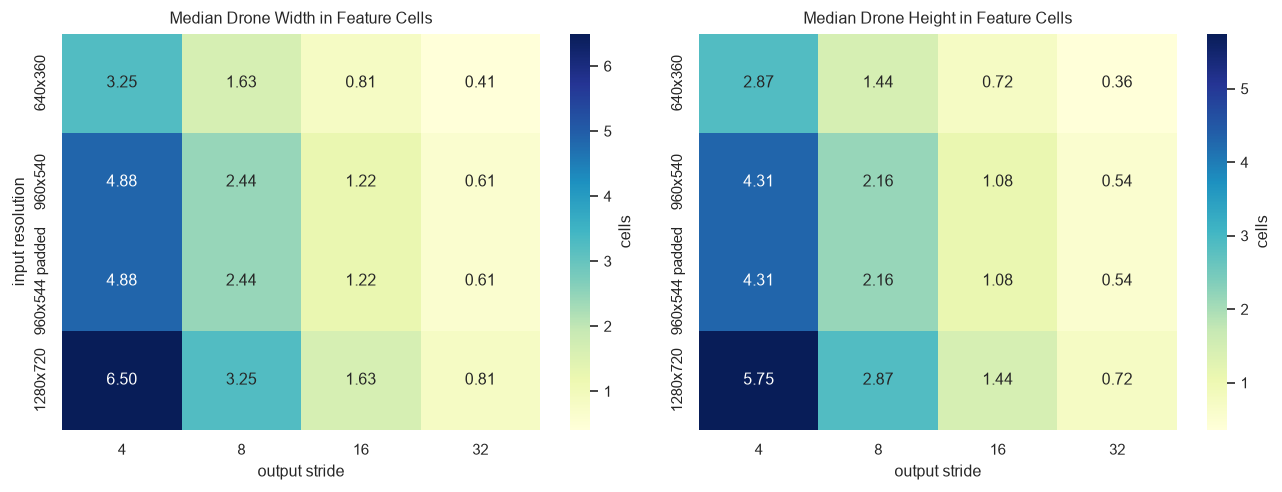

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
heat_w = resolution_stride_df.pivot(index="resolution", columns="stride", values="median_width_cells").loc[[r["name"] for r in candidate_resolutions]]
heat_h = resolution_stride_df.pivot(index="resolution", columns="stride", values="median_height_cells").loc[[r["name"] for r in candidate_resolutions]]

sns.heatmap(heat_w, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "cells"})
axes[0].set_title("Median Drone Width in Feature Cells")
axes[0].set_xlabel("output stride")
axes[0].set_ylabel("input resolution")

sns.heatmap(heat_h, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1], cbar_kws={"label": "cells"})
axes[1].set_title("Median Drone Height in Feature Cells")
axes[1].set_xlabel("output stride")
axes[1].set_ylabel("")
fig.tight_layout()
save_figure(fig, "detector_resolution_stride_analysis")
plt.show()

### Resolution Interpretation

- At `640x360`, the median drone is roughly `13x11 px`. At stride 8 it spans only about 1.6 by 1.4 cells, which is fragile for precise localization.
- At `1280x720`, the median drone is roughly `26x23 px`. This is better, but the stride-8 map has `160x90 = 14,400` locations before any multi-channel head work.
- `960x540` is a compromise: the median drone remains around `20x17 px`; a stride-8 map gives about 2.5 by 2.1 cells across the median drone.
- `960x544 padded` is implementation-friendly because width and height are divisible by 32 while changing the visual content minimally.

For an Apple M1 8 GB machine, `960x544` with small batch sizes is more realistic than `1280x720`. For later GPU training, `1280x720` should remain a high-value ablation because small-object scale is the primary challenge.

## 5. Backbone Design from Scratch

The backbone should be randomly initialized and built only from primitive PyTorch layers such as `Conv2d`, normalization, activation, pooling/upsampling, and residual additions.

Baseline design principles:

- avoid stride-4 or stride-8 immediately in the stem;
- use small convolutional blocks to preserve local detail;
- produce stride-8, stride-16, and stride-32 features;
- fuse deeper context back to stride 8 for prediction;
- keep channels modest for local development.

Proposed primitive block for later implementation:

\[
\text{ConvBlock}(C_{in}, C_{out}, s) = \text{SiLU}(\text{BN}(\text{Conv}_{3\times3,s}(C_{in}, C_{out}))).
\]

A residual block at fixed resolution:

\[
y = x + F(x),
\]

where \(F\) is two `3x3` Conv-BN-SiLU style blocks, with the second activation applied after addition. Residuals are justified here because they add optimization stability without importing a pretrained or named backbone.

In [6]:
def conv_params(cin: int, cout: int, kernel: int = 3, bias: bool = False) -> int:
    return kernel * kernel * cin * cout + (cout if bias else 0)

# Rough conceptual parameter count: convolution kernels only plus BN affine params.
def conv_bn_params(cin: int, cout: int, kernel: int = 3) -> int:
    return conv_params(cin, cout, kernel, bias=False) + 2 * cout

backbone_rows = [
    {"stage": "input", "input": "-", "operation": "RGB tensor", "channels": 3, "stride": 1, "output": "960x544", "total_stride": 1, "params_approx": 0},
    {"stage": "stem", "input": "960x544", "operation": "3x3 conv, s=2", "channels": 24, "stride": 2, "output": "480x272", "total_stride": 2, "params_approx": conv_bn_params(3, 24)},
    {"stage": "stage 2", "input": "480x272", "operation": "3x3 conv s=2 + 1 residual block", "channels": 48, "stride": 2, "output": "240x136", "total_stride": 4, "params_approx": conv_bn_params(24, 48) + 2 * conv_bn_params(48, 48)},
    {"stage": "stage 3", "input": "240x136", "operation": "3x3 conv s=2 + 2 residual blocks", "channels": 96, "stride": 2, "output": "120x68", "total_stride": 8, "params_approx": conv_bn_params(48, 96) + 4 * conv_bn_params(96, 96)},
    {"stage": "stage 4", "input": "120x68", "operation": "3x3 conv s=2 + 2 residual blocks", "channels": 160, "stride": 2, "output": "60x34", "total_stride": 16, "params_approx": conv_bn_params(96, 160) + 4 * conv_bn_params(160, 160)},
    {"stage": "stage 5", "input": "60x34", "operation": "3x3 conv s=2 + 1 residual block", "channels": 224, "stride": 2, "output": "30x17", "total_stride": 32, "params_approx": conv_bn_params(160, 224) + 2 * conv_bn_params(224, 224)},
]
backbone_df = pd.DataFrame(backbone_rows)
display_df(backbone_df, "Proposed custom CNN backbone: conceptual shape table")
print(f"Approximate convolution+BN parameters: {backbone_df['params_approx'].sum():,}")

**Proposed custom CNN backbone: conceptual shape table**

,stage,input,operation,channels,stride,output,total_stride,params_approx
0,input,-,RGB tensor,3,1,960x544,1,0
1,stem,960x544,"3x3 conv, s=2",24,2,480x272,2,696
2,stage 2,480x272,3x3 conv s=2 + 1 residual block,48,2,240x136,4,52128
3,stage 3,240x136,3x3 conv s=2 + 2 residual blocks,96,2,120x68,8,374208
4,stage 4,120x68,3x3 conv s=2 + 2 residual blocks,160,2,60x34,16,1061440
5,stage 5,60x34,3x3 conv s=2 + 1 residual block,224,2,30x17,32,1227072


Approximate convolution+BN parameters: 2,715,544


## 6. Feature Fusion / Multi-Scale Context

A single stride-8 feature head sees useful spatial detail, but tiny drones can be confused with windows, tree branches, sun glare, or other background texture. Deeper context can help distinguish a drone-shaped blob from background.

Compared options:

### Single Stride-8 Head

- Uses only the stride-8 feature map.
- Cheapest and simplest.
- Risk: insufficient semantic/contextual discrimination.

### Stride-8 Head Enriched by Stride-16/32 Context

- Compute stride-16 and stride-32 features in the backbone.
- Project each feature to a common channel count with `1x1` convolutions.
- Upsample stride-16 by `2x` and stride-32 by `4x` using bilinear interpolation or nearest-neighbor interpolation.
- Concatenate or add them with the stride-8 projection.
- Apply a small `3x3` refinement block before prediction.

This is not an imported feature pyramid. It is a simple custom context-fusion path derived from the tiny-object problem.

### Multi-Head Alternative

- Predict at stride 8 and stride 16.
- Could help larger objects, but this dataset has consistently tiny objects.
- Adds assignment and duplicate-removal complexity.

**Selected first baseline:** one stride-8 prediction head enriched by projected stride-16 and stride-32 context. This is the simplest defensible compromise between spatial precision and contextual information.

## 7. Detection Head

For input canvas \(H \times W = 544 \times 960\) and output stride \(S=8\), the prediction map has:

\[
H_g = 68, \quad W_g = 120.
\]

Each grid location predicts five scalar values:

\[
\hat{Y}_{i,j} = (z^{obj}_{i,j}, z^x_{i,j}, z^y_{i,j}, t^w_{i,j}, t^h_{i,j}).
\]

Output tensor shape:

\[
B \times 5 \times 68 \times 120.
\]

Decode for cell \((i, j)\):

\[
p_{i,j} = \sigma(z^{obj}_{i,j})
\]

\[
\hat{x} = \frac{j + \sigma(z^x_{i,j})}{W_g}, \quad
\hat{y} = \frac{i + \sigma(z^y_{i,j})}{H_g}
\]

\[
\hat{w} = \exp(t^w_{i,j}), \quad
\hat{h} = \exp(t^h_{i,j})
\]

where \(\hat{x}, \hat{y}, \hat{w}, \hat{h}\) are normalized to the padded input canvas.

Positive target assignment:

- assign each ground-truth object to the cell containing its adjusted center;
- target offsets are the fractional center position inside that cell;
- target sizes are \(\log(w_{norm})\) and \(\log(h_{norm})\);
- objectness target is `1` for assigned cells and `0` for unassigned cells.

Multiple objects:

- if two object centers fall in different cells, each gets its own positive cell;
- if two centers fall into the same cell, keep the smaller-area object only for the first baseline and record a collision counter;
- if collisions become common, later ablate multi-radius assignment or a second prediction slot per cell.

Cell boundaries:

- an object near a boundary is assigned to the cell containing its center;
- center-offset regression still gives sub-cell precision;
- a later controlled ablation can mark a small neighborhood around the center as soft positives if boundary instability appears.

## 8. Objective Function Design

Let \(\Omega\) be all grid locations and \(P \subset \Omega\) be positive assigned locations. For each location \(u\), objectness target \(q_u \in \{0,1\}\).

### Objectness Loss

Foreground/background imbalance is severe. At `960x544` with stride 8, there are `68 x 120 = 8,160` cells and typically only two positives per image.

Use weighted binary cross entropy or a focal-style variant. Focal loss is an established idea; if adopted, we should label it as such, not as a novel contribution.

Weighted BCE form:

\[
L_{obj} = - \frac{1}{|\Omega|} \sum_{u \in \Omega}
\alpha_u \left[q_u \log p_u + (1-q_u) \log(1-p_u)\right]
\]

with \(\alpha_u = \alpha_{pos}\) for positives and \(\alpha_{neg}\) for negatives. A reasonable starting point is to normalize positive and negative contributions separately rather than letting negatives dominate.

### Localization Loss

Only positives contribute to localization:

\[
L_{center} = \frac{1}{|P|} \sum_{u \in P}
\text{SmoothL1}(\hat{\delta x}_u, \delta x_u) + \text{SmoothL1}(\hat{\delta y}_u, \delta y_u)
\]

\[
L_{size} = \frac{1}{|P|} \sum_{u \in P}
\text{SmoothL1}(\hat{t}^w_u, \log w_u) + \text{SmoothL1}(\hat{t}^h_u, \log h_u)
\]

Optional own-IoU term:

\[
L_{iou} = \frac{1}{|P|} \sum_{u \in P} (1 - IoU(\hat{b}_u, b_u)).
\]

IoU mathematics should be implemented directly later from `xyxy` boxes.

Composite objective:

\[
L = \lambda_{obj} L_{obj} + \lambda_{center} L_{center} + \lambda_{size} L_{size} + \lambda_{iou} L_{iou}.
\]

Initial candidate weights for the first implementation:

- \(\lambda_{obj}=1.0\)
- \(\lambda_{center}=5.0\)
- \(\lambda_{size}=2.0\)
- \(\lambda_{iou}=1.0\), initially optional if decoding stability is not ready

Small-object weighting may be useful, for example clipping a factor based on inverse relative area, but it should be an ablation rather than baked into the first result.

## 9. Target Encoding Example

The following uses synthetic/example annotation values in YOLO-normalized format. It demonstrates the proposed target transformation without altering the dataset.

In [7]:
example_annotations = pd.DataFrame([
    {"class_id": 0, "x_center_norm": 0.552148, "y_center_norm": 0.356597, "width_norm": 0.017578, "height_norm": 0.038194},
    {"class_id": 0, "x_center_norm": 0.593945, "y_center_norm": 0.746875, "width_norm": 0.038672, "height_norm": 0.065972},
])

INPUT_W = 960
CONTENT_H = 540
INPUT_H = 544
PAD_TOP = (INPUT_H - CONTENT_H) / 2
STRIDE = 8
GRID_W = INPUT_W // STRIDE
GRID_H = INPUT_H // STRIDE

encoded_rows = []
for _, row in example_annotations.iterrows():
    # Resize original 2560x1440 to 960x540, then pad to 960x544.
    x_canvas_px = row["x_center_norm"] * INPUT_W
    y_canvas_px = row["y_center_norm"] * CONTENT_H + PAD_TOP
    w_canvas_px = row["width_norm"] * INPUT_W
    h_canvas_px = row["height_norm"] * CONTENT_H

    x_canvas_norm = x_canvas_px / INPUT_W
    y_canvas_norm = y_canvas_px / INPUT_H
    w_canvas_norm = w_canvas_px / INPUT_W
    h_canvas_norm = h_canvas_px / INPUT_H

    cell_j = int(np.floor(x_canvas_px / STRIDE))
    cell_i = int(np.floor(y_canvas_px / STRIDE))
    offset_x = x_canvas_px / STRIDE - cell_j
    offset_y = y_canvas_px / STRIDE - cell_i

    encoded_rows.append({
        "class_id": int(row["class_id"]),
        "x_canvas_norm": x_canvas_norm,
        "y_canvas_norm": y_canvas_norm,
        "w_canvas_norm": w_canvas_norm,
        "h_canvas_norm": h_canvas_norm,
        "grid_i": cell_i,
        "grid_j": cell_j,
        "offset_x_target": offset_x,
        "offset_y_target": offset_y,
        "log_w_target": np.log(w_canvas_norm),
        "log_h_target": np.log(h_canvas_norm),
        "objectness_target": 1,
        "box_width_px_at_input": w_canvas_px,
        "box_height_px_at_input": h_canvas_px,
    })

encoded_example_df = pd.DataFrame(encoded_rows)
display_df(encoded_example_df, "Example anchor-free target encoding at 960x544, stride 8")
print(f"Grid shape: {GRID_H} x {GRID_W}; total cells: {GRID_H * GRID_W}")

**Example anchor-free target encoding at 960x544, stride 8**

,class_id,x_canvas_norm,y_canvas_norm,w_canvas_norm,h_canvas_norm,grid_i,grid_j,offset_x_target,offset_y_target,log_w_target,log_h_target,objectness_target,box_width_px_at_input,box_height_px_at_input
0,0,0.552148,0.357651,0.017578,0.037913,24,66,0.25776,0.320297,-4.041107,-3.272457,1,16.87488,20.62476
1,0,0.593945,0.745060,0.038672,0.065487,50,71,0.27340,0.664062,-3.252639,-2.725905,1,37.12512,35.62488


Grid shape: 68 x 120; total cells: 8160


## 10. Inference and Post-Processing

Planned inference procedure:

1. Run the network on a resized/padded image canvas.
2. Decode every grid cell into objectness and normalized `xyxy` boxes.
3. Discard boxes with invalid dimensions or coordinates outside a tolerable range.
4. Apply a confidence threshold.
5. Keep top-K candidates per image before NMS for computational stability.
6. Apply non-maximum suppression.
7. Map detections back from padded canvas coordinates to original image coordinates.

NMS should be implemented directly later:

- sort candidates by confidence;
- repeatedly keep the highest-confidence box;
- remove remaining boxes with IoU above threshold;
- continue until no candidates remain or max detections is reached.

Thresholds such as objectness cutoff, top-K, and NMS IoU must be tuned only on train/validation data. The sealed test set should be used once for final reporting.

## 11. Evaluation Framework

Primary metrics for later implementation:

- `IoU`: geometric overlap between predicted and ground-truth boxes.
- `precision`: fraction of predicted detections that are true positives.
- `recall`: fraction of ground-truth drones detected.
- `F1`: harmonic mean of precision and recall.
- `AP@0.50`: area under precision-recall curve at IoU threshold 0.50.
- `AP@0.75`: stricter localization metric.
- `mAP@[0.50:0.95]`: mean AP over IoU thresholds. In this single-class dataset, mAP is the mean over thresholds, not over multiple semantic classes.
- object-size-specific recall/AP, especially for objects with either dimension below 16, 32, and 64 px at evaluation scale.
- scene/weather breakdown.
- raw vs augmented breakdown.
- latency/FPS.
- parameter count and approximate activation memory.

Primary recommendation:

- Use validation `AP@0.50`, `AP@0.75`, and small-object recall as the main development metrics.
- Use confidence-thresholded precision/recall/F1 for operational interpretability.
- Report final sealed-test metrics only after architecture, loss weights, and thresholds are frozen.

## 12. Proposed First Baseline Architecture

Temporary name: **S8-CFD: Stride-8 Context-Fused Drone Detector**.

Concrete proposal:

- input resolution: resize source image to `960x540`, then pad to `960x544`;
- backbone: custom randomly initialized CNN with total strides 2, 4, 8, 16, and 32;
- feature fusion: project stride-8/16/32 features to a common width, upsample deeper features, concatenate at stride 8, refine with primitive convolutions;
- output stride: 8;
- detection head: one `1x1` or small `3x3 + 1x1` head predicting five channels per cell;
- output tensor: `B x 5 x 68 x 120`;
- representation: objectness, center offsets, log-normalized width, log-normalized height;
- objective: weighted objectness BCE plus Smooth L1 center/size losses, with optional direct IoU loss;
- optimizer candidate: AdamW as a practical first optimizer for randomly initialized CNNs;
- initial learning-rate candidate: `1e-3`, with warmup or reduction if instability appears;
- batch-size consideration: start with small batches, likely `1-4` on Apple M1 8 GB at `960x544`; use gradient accumulation if needed;
- later GPU training: ablate `1280x720` and/or stride-4 prediction if compute allows.

This is intentionally a baseline, not a final system. It leaves room for controlled improvements.

In [8]:
fusion_rows = [
    {"component": "P8 projection", "input_feature": "stage 3, 120x68x96", "operation": "1x1 conv to 96 channels", "output": "120x68x96"},
    {"component": "P16 context", "input_feature": "stage 4, 60x34x160", "operation": "1x1 conv to 96, upsample 2x", "output": "120x68x96"},
    {"component": "P32 context", "input_feature": "stage 5, 30x17x224", "operation": "1x1 conv to 96, upsample 4x", "output": "120x68x96"},
    {"component": "fusion", "input_feature": "concat(P8, P16, P32)", "operation": "3x3 conv refinement to 128 channels", "output": "120x68x128"},
    {"component": "head", "input_feature": "120x68x128", "operation": "3x3 conv + 1x1 conv", "output": "120x68x5"},
]
display_df(pd.DataFrame(fusion_rows), "S8-CFD feature-fusion and head table")

**S8-CFD feature-fusion and head table**

,component,input_feature,operation,output
0,P8 projection,"stage 3, 120x68x96",1x1 conv to 96 channels,120x68x96
1,P16 context,"stage 4, 60x34x160","1x1 conv to 96, upsample 2x",120x68x96
2,P32 context,"stage 5, 30x17x224","1x1 conv to 96, upsample 4x",120x68x96
3,fusion,"concat(P8, P16, P32)",3x3 conv refinement to 128 channels,120x68x128
4,head,120x68x128,3x3 conv + 1x1 conv,120x68x5


## 13. Planned Ablations

Prioritized experiment matrix for after implementation:

1. **Input resolution**: `640x360`, `960x544`, `1280x720`. Highest value because object scale is the dominant dataset difficulty.
2. **Output stride**: stride 8 baseline versus stride 4 variant. High value if localization recall is poor; expensive because stride 4 quadruples prediction locations.
3. **Feature fusion**: stride-8 only versus stride-8 enriched with stride-16/32 context. Tests whether deeper context helps separate drones from background clutter.
4. **Objectness imbalance handling**: weighted BCE versus focal-style objectness. High value because positives are roughly 2 out of 8,160 cells per image at stride 8.
5. **Localization objective**: Smooth L1 only versus Smooth L1 plus direct IoU term.
6. **Backbone capacity**: smaller/larger channel multipliers after the baseline runs.
7. **Augmentation policy**: conservative photometric/geometric augmentations after establishing a non-augmented training baseline.

Experiments should be selected using train/validation only. The sealed test set remains untouched until final evaluation.

## 14. Risks and Open Questions

Design risks:

- Tiny objects may become too small after resizing, especially below `960x544`.
- Dense prediction creates severe foreground/background imbalance.
- Center assignment can be unstable for objects near cell boundaries.
- One-object-per-cell assignment may fail if two centers collide in the same stride-8 cell.
- Synthetic/rendered regularities may inflate validation performance.
- Only ten capture-pair groups exist, limiting independence and split granularity.
- Apple M1 8 GB memory may constrain batch size, resolution, and activation-heavy fusion.
- The dataset has only one semantic class, so classification quality may be less informative than localization/objectness quality.

Open questions:

- Does `capture_pair` truly identify drone/source identity?
- Are neighboring sequence indices temporally adjacent or independently sampled?
- How well does this synthetic distribution transfer to real drone imagery?
- Are there unlabeled hard negatives available, or only positive images?
- How frequently do positive centers collide at stride 8 after target encoding?

**Concise recommendation:** implement S8-CFD first: a custom anchor-free, stride-8, context-fused detector at `960x544` with weighted objectness loss and Smooth L1 center/size regression. The 3-5 highest-value follow-up experiments are input resolution, output stride, feature fusion, objectness imbalance handling, and adding a direct IoU localization term.